# RQ2 Notebook 05 — Exposure Burden

**RQ2.3: How much total downstream exposure does each upstream vulnerability generate?**

Notebook 03 measured **breadth** — how many projects are exposed. Notebook 04 measured
**duration** — how long exposure lasts. Neither alone answers "impact": a CVE affecting 4,000
projects patched in a week and one affecting 3 projects patched over three years are very
different, and each looks severe on one axis only.

Burden multiplies them.

**Input:** `rq2_master_pairwise.csv` (1,677 pairs) and `rq2_blast_radius_per_cve.csv`.
**Produces:** `T5`, `T6`, `F5`, `F6`.

> **Burden is a lower bound.** It sums over *observed* mitigations only. `RESPONSE.csv` covers
> 191 of 832 CVEs and misses the largest-blast-radius vulnerabilities entirely (notebook 03:
> the top 15 by exposure have zero observed mitigations). No figure here should be read as
> total ecosystem exposure.

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln

pd.set_option('display.width', 230)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(20260811)

OUT = Path('../../data/rq2')

master = pd.read_csv(OUT / 'rq2_master_pairwise.csv')
blast  = pd.read_csv(OUT / 'rq2_blast_radius_per_cve.csv')

PATTERN_ORDER = ['S1', 'S2', 'S3', 'T1', 'T2', 'T3', 'T5']

print(f'pairs {len(master):,} | CVEs {master.CVE.nunique()} | repos {master.downstream_repo.nunique()}')

pairs 1,677 | CVEs 191 | repos 742


---
## Step 1 — Per-pair exposure days

For each anchor `A`, a pair contributes to burden only if it was still exposed when `A`
passed — that is, `delay_A > 0`. Pairs that mitigated before the anchor contribute nothing:
they were never exposed at that stage.

```
exposed_past_A   =  delay_A > 0
exposure_days_A  =  delay_A   where exposed, else 0
```

**Two anchors, two questions:**

| Anchor | Question it answers |
|---|---|
| **Disclosure** (primary) | How long did projects run vulnerable code that was *already public*? |
| **Release** (secondary) | How long did projects stay vulnerable while a *fixed version already existed*? |

The release-anchored figure is the one RQ1's "available adoption window" argument predicts
should be small.

In [24]:
for a in ['fix', 'release', 'disclosure']:
    master[f'exposed_past_{a}'] = (master[f'delay_{a}'] > 0).astype(int)
    master[f'exposure_days_{a}'] = master[f'delay_{a}'].clip(lower=0)

pair_summary = []
for a in ['fix', 'release', 'disclosure']:
    e = master[f'exposed_past_{a}']
    d = master.loc[e == 1, f'delay_{a}']
    pair_summary.append({
        'Anchor': a,
        'Pairs exposed past anchor': int(e.sum()),
        '% of pairs': round(100 * e.mean(), 1),
        'Median exposure days': round(d.median(), 1),
        'IQR': f'[{d.quantile(.25):.0f}, {d.quantile(.75):.0f}]',
        'Total burden (downstream-days)': int(master[f'exposure_days_{a}'].sum()),
    })
display(pd.DataFrame(pair_summary))
print('Note: 100% of pairs are exposed past the fix by construction — the Step 10b filter')
print('removed every pair whose adoption predates the upstream fix. The total is meaningful;')
print('the percentage is not.')

print(f"PRIMARY   Burden(disclosure) = {master.exposure_days_disclosure.sum():,.0f} downstream-days")
print(f"SECONDARY Burden(release)    = {master.exposure_days_release.sum():,.0f} downstream-days")
print()
print(f"In plain terms: across {master.exposure_days_disclosure.gt(0).sum():,} observed pairs,")
print(f"downstream projects spent {master.exposure_days_disclosure.sum() / 365.25:,.0f} project-years")
print("running code with a publicly known vulnerability.")

,Anchor,Pairs exposed past anchor,% of pairs,Median exposure days,IQR,Total burden (downstream-days)
0,fix,1677,100.0,125.5,"[54, 392]",545557
1,release,1615,96.3,96.3,"[17, 354]",481648
2,disclosure,1430,85.3,88.1,"[18, 302]",360556


Note: 100% of pairs are exposed past the fix by construction — the Step 10b filter
removed every pair whose adoption predates the upstream fix. The total is meaningful;
the percentage is not.
PRIMARY   Burden(disclosure) = 360,557 downstream-days
SECONDARY Burden(release)    = 481,648 downstream-days

In plain terms: across 1,430 observed pairs,
downstream projects spent 987 project-years
running code with a publicly known vulnerability.


---
## Step 2 — Per-CVE burden

Total burden per CVE is partly an artefact of how many of its pairs were observed: a CVE with
24 mined mitigations will out-total one with 2 regardless of behaviour.

So three quantities are kept side by side, and comparisons across CVEs use the third:

| Quantity | Confounded by observation count? |
|---|---|
| Total burden | **yes** — use for aggregates only |
| Observed pairs | — |
| **Mean burden per pair** | **no** — use for comparisons |

In [25]:
cve_burden = (
    master.groupby('CVE')
    .agg(pairs=('CVE', 'size'),
         exposed_past_disclosure=('exposed_past_disclosure', 'sum'),
         burden_disclosure=('exposure_days_disclosure', 'sum'),
         exposed_past_release=('exposed_past_release', 'sum'),
         burden_release=('exposure_days_release', 'sum'),
         median_delay_disclosure=('delay_disclosure', 'median'))
    .reset_index()
)
cve_burden['burden_per_pair'] = cve_burden.burden_disclosure / cve_burden.pairs

meta = master.drop_duplicates('CVE')[['CVE', 'class', 'pattern', 'severity', 'dependents']]
cve_burden = cve_burden.merge(meta, on='CVE', how='left')

TOTAL_BURDEN = cve_burden.burden_disclosure.sum()
cve_burden['% of total burden'] = (100 * cve_burden.burden_disclosure / TOTAL_BURDEN).round(2)

print(f'CVEs with burden data: {len(cve_burden)}')
print(f'CVEs with zero burden (all pairs mitigated before disclosure): '
      f'{int((cve_burden.burden_disclosure == 0).sum())}')
display(cve_burden.describe()[['pairs', 'burden_disclosure', 'burden_per_pair', 'dependents']].round(1))

CVEs with burden data: 191
CVEs with zero burden (all pairs mitigated before disclosure): 8


,pairs,burden_disclosure,burden_per_pair,dependents
count,191.0,191.0,191.0,191.0
mean,8.8,1887.7,257.2,78.1
std,9.1,2539.8,269.8,67.2
min,1.0,0.0,0.0,12.0
25%,3.0,355.5,52.3,24.5
50%,6.0,981.3,163.9,47.0
75%,12.0,2123.7,351.6,134.0
max,71.0,15030.3,1345.3,303.0


---
## T5 — Burden by pattern

In [26]:
rows = []
for pat in PATTERN_ORDER:
    sub = master[master.pattern.eq(pat)]
    if sub.empty:
        continue
    cs = cve_burden[cve_burden.pattern.eq(pat)]
    dd = sub.loc[sub.exposed_past_disclosure == 1, 'delay_disclosure']
    dr = sub.loc[sub.exposed_past_release == 1, 'delay_release']
    rows.append({
        'Pattern': pat, 'Class': sub['class'].iloc[0],
        'CVEs': sub.CVE.nunique(), 'Pairs': len(sub),
        'Exposed past disclosure': int(sub.exposed_past_disclosure.sum()),
        'Median days [IQR]': f'{dd.median():.0f} [{dd.quantile(.25):.0f}, {dd.quantile(.75):.0f}]' if len(dd) else 'NA',
        'Burden(disclosure)': int(sub.exposure_days_disclosure.sum()),
        'Burden per pair': round(sub.exposure_days_disclosure.mean(), 1),
        'Exposed past release': int(sub.exposed_past_release.sum()),
        'Burden(release)': int(sub.exposure_days_release.sum()),
        '% of total burden': round(100 * sub.exposure_days_disclosure.sum() / TOTAL_BURDEN, 1),
    })

T5 = pd.DataFrame(rows)
display(T5)

by_class = []
for c in ['Silent', 'Transparent']:
    sub = master[master['class'].eq(c)]
    by_class.append({
        'Class': c, 'CVEs': sub.CVE.nunique(), 'Pairs': len(sub),
        'Burden(disclosure)': int(sub.exposure_days_disclosure.sum()),
        'Burden per pair': round(sub.exposure_days_disclosure.mean(), 1),
        'Burden(release)': int(sub.exposure_days_release.sum()),
        'Burden per pair (release)': round(sub.exposure_days_release.mean(), 1),
        '% of total burden': round(100 * sub.exposure_days_disclosure.sum() / TOTAL_BURDEN, 1),
    })
display(pd.DataFrame(by_class))

print('Burden per pair is the comparable column. Total burden reflects how many pairs')
print('were observed for each group, not only how long exposure lasted.')

,Pattern,Class,CVEs,Pairs,Exposed past disclosure,Median days [IQR],Burden(disclosure),Burden per pair,Exposed past release,Burden(release),% of total burden
0,S1,Silent,95,1012,894,"87 [15, 317]",235382,232.6,1005,332689,65.3
1,S2,Silent,6,68,68,"111 [45, 290]",18050,265.5,49,14976,5.0
2,S3,Silent,4,20,20,"127 [119, 253]",4554,227.7,12,2852,1.3
3,T1,Transparent,75,521,399,"68 [16, 242]",79396,152.4,510,112536,22.0
4,T2,Transparent,6,34,27,"226 [52, 961]",13142,386.5,18,11813,3.6
5,T3,Transparent,4,21,21,"411 [116, 542]",9941,473.4,20,6696,2.8
6,T5,Transparent,1,1,1,"89 [89, 89]",88,88.5,1,83,0.0


,Class,CVEs,Pairs,Burden(disclosure),Burden per pair,Burden(release),Burden per pair (release),% of total burden
0,Silent,105,1100,257988,234.5,350518,318.7,71.6
1,Transparent,86,577,102568,177.8,131129,227.3,28.4


Burden per pair is the comparable column. Total burden reflects how many pairs
were observed for each group, not only how long exposure lasted.


---
## T6 — Top 15 CVEs by burden

These are the vulnerabilities that generated the most observed downstream exposure. Compare
against notebook 03's `T2` (top by breadth): the overlap tells you whether wide reach and slow
mitigation are the same problem or two different ones.

In [27]:
T6 = (
    cve_burden.nlargest(15, 'burden_disclosure')
    [['CVE', 'severity', 'class', 'pattern', 'dependents', 'pairs',
      'exposed_past_disclosure', 'median_delay_disclosure', 'burden_disclosure',
      'burden_per_pair', '% of total burden']]
    .round(1)
)
display(T6)

print(f'These 15 CVEs account for {T6["% of total burden"].sum():.1f}% of observed burden.')

top_breadth = set(blast.nlargest(15, 'dependents').CVE_ID)
overlap = set(T6.CVE) & top_breadth
print(f'Overlap with notebook 03 top-15 by breadth: {len(overlap)} CVEs {sorted(overlap) if overlap else ""}')
print('Zero overlap means breadth and burden identify DIFFERENT vulnerabilities as worst.')

,CVE,severity,class,pattern,dependents,pairs,exposed_past_disclosure,median_delay_disclosure,burden_disclosure,burden_per_pair,% of total burden
4,CVE-2013-6429,Medium,Silent,S1,185,19,16,515.8,15030.3,791.1,4.2
1,CVE-2011-2894,Medium,Silent,S1,185,20,17,289.2,14018.9,700.9,3.9
9,CVE-2014-3578,Medium,Silent,S1,185,14,12,536.9,11136.9,795.5,3.1
34,CVE-2016-3674,Medium,Silent,S1,169,18,14,415.3,9748.3,541.6,2.7
111,CVE-2019-12402,Medium,Silent,S1,303,71,69,72.8,9353.2,131.7,2.6
49,CVE-2017-1000487,High,Silent,S1,248,12,11,691.3,8441.3,703.4,2.3
52,CVE-2017-17485,High,Transparent,T1,172,29,28,131.7,8369.0,288.6,2.3
67,CVE-2018-1000180,Medium,Silent,S2,156,28,28,152.4,8077.2,288.5,2.2
68,CVE-2018-1000613,High,Silent,S1,156,29,25,87.5,7289.0,251.3,2.0
97,CVE-2018-8009,Medium,Transparent,T2,134,10,10,678.1,7223.1,722.3,2.0


These 15 CVEs account for 36.5% of observed burden.
Overlap with notebook 03 top-15 by breadth: 0 CVEs 
Zero overlap means breadth and burden identify DIFFERENT vulnerabilities as worst.


---
## Concentration — is burden more concentrated than breadth?

**The comparison must use the same CVEs.** Notebook 03's breadth Gini (0.813) is computed over
all 832 CVEs; burden exists only for the 191 with observed mitigations. Comparing those two
numbers directly would confuse concentration with coverage.

So breadth is recomputed here on the same 191 CVEs, and the difference is bootstrapped.

In [28]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def lorenz(x):
    x = np.sort(np.asarray(x, dtype=float))
    return (np.insert(np.arange(1, len(x) + 1) / len(x), 0, 0),
            np.insert(np.cumsum(x) / x.sum(), 0, 0))

burden_vals  = cve_burden.burden_disclosure.values
breadth_vals = cve_burden.dependents.values

g_burden, g_breadth = gini(burden_vals), gini(breadth_vals)
idx = np.arange(len(cve_burden))
diffs, gb, gr = [], [], []
for _ in range(2000):
    s = rng.choice(idx, len(idx), replace=True)
    a, b = gini(burden_vals[s]), gini(breadth_vals[s])
    gb.append(a); gr.append(b); diffs.append(a - b)

display(pd.DataFrame([
    {'Measure': 'Burden (disclosure)', 'Gini': round(g_burden, 3),
     'CI low': round(np.percentile(gb, 2.5), 3), 'CI high': round(np.percentile(gb, 97.5), 3)},
    {'Measure': 'Breadth, same 191 CVEs', 'Gini': round(g_breadth, 3),
     'CI low': round(np.percentile(gr, 2.5), 3), 'CI high': round(np.percentile(gr, 97.5), 3)},
    {'Measure': 'Difference (burden - breadth)', 'Gini': round(g_burden - g_breadth, 3),
     'CI low': round(np.percentile(diffs, 2.5), 3), 'CI high': round(np.percentile(diffs, 97.5), 3)},
]))

conc = []
for q in [1, 5, 10, 25]:
    k = max(1, int(np.ceil(len(cve_burden) * q / 100)))
    conc.append({'Top % of CVEs': q, 'CVEs': k,
                 'Share of burden %': round(100 * np.sort(burden_vals)[::-1][:k].sum() / burden_vals.sum(), 1),
                 'Share of breadth %': round(100 * np.sort(breadth_vals)[::-1][:k].sum() / breadth_vals.sum(), 1)})
display(pd.DataFrame(conc))

sig = 'YES' if (np.percentile(diffs, 2.5) > 0 or np.percentile(diffs, 97.5) < 0) else 'NO'
print(f'Difference significant: {sig}')
print()
print('CAUTION on interpretation. Burden = pairs x days, so it multiplies two varying')
print('quantities and will disperse more than either one even when they are unrelated.')
print('A larger burden Gini therefore does NOT by itself show that broad CVEs are also')
print('slow. That question is answered by the correlation in F6 below.')

,Measure,Gini,CI low,CI high
0,Burden (disclosure),0.608,0.561,0.646
1,"Breadth, same 191 CVEs",0.456,0.426,0.480
2,Difference (burden - breadth),0.152,0.103,0.196


,Top % of CVEs,CVEs,Share of burden %,Share of breadth %
0,1,2,8.1,4.1
1,5,10,27.4,15.8
2,10,20,45.4,27.9
3,25,48,70.3,57.5


Difference significant: YES

CAUTION on interpretation. Burden = pairs x days, so it multiplies two varying
quantities and will disperse more than either one even when they are unrelated.
A larger burden Gini therefore does NOT by itself show that broad CVEs are also
slow. That question is answered by the correlation in F6 below.


---
## F5 — Lorenz curves, burden against breadth

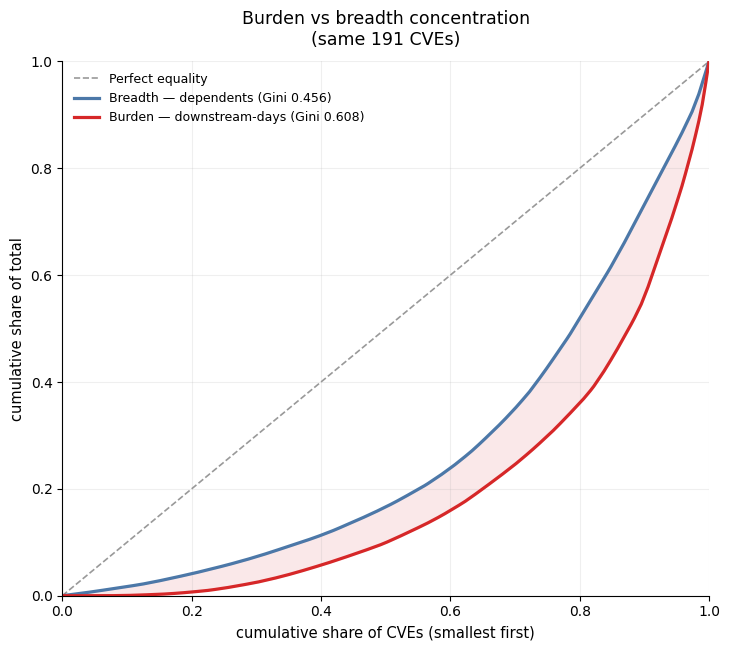

In [29]:
fb, cb = lorenz(burden_vals)
fr_, cr = lorenz(breadth_vals)

fig, ax = plt.subplots(figsize=(7.4, 6.6))
ax.plot([0, 1], [0, 1], color='#999999', ls='--', lw=1.2, label='Perfect equality')
ax.plot(fr_, cr, color='#4c78a8', lw=2.3, label=f'Breadth — dependents (Gini {g_breadth:.3f})')
ax.plot(fb, cb, color='#d62728', lw=2.3, label=f'Burden — downstream-days (Gini {g_burden:.3f})')
ax.fill_between(fb, cb, np.interp(fb, fr_, cr), color='#d62728', alpha=0.10)

ax.set_xlabel('cumulative share of CVEs (smallest first)', fontsize=10.5)
ax.set_ylabel('cumulative share of total', fontsize=10.5)
ax.set_title('Burden vs breadth concentration\n(same 191 CVEs)', fontsize=12.5, pad=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(alpha=0.2)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F5_lorenz_burden_vs_breadth.png', dpi=200, bbox_inches='tight')
plt.show()

---
## F6 — Where breadth and duration meet

Each point is a CVE. Reach on the x-axis, typical delay on the y-axis, point size is total
burden. The **upper-right quadrant is the worst case**: many dependents *and* slow mitigation.

The correlation printed below decides how to read the Gini gap above. If it is near zero,
reach and duration are independent risk axes and the wider burden dispersion is arithmetic
rather than a compounding effect.

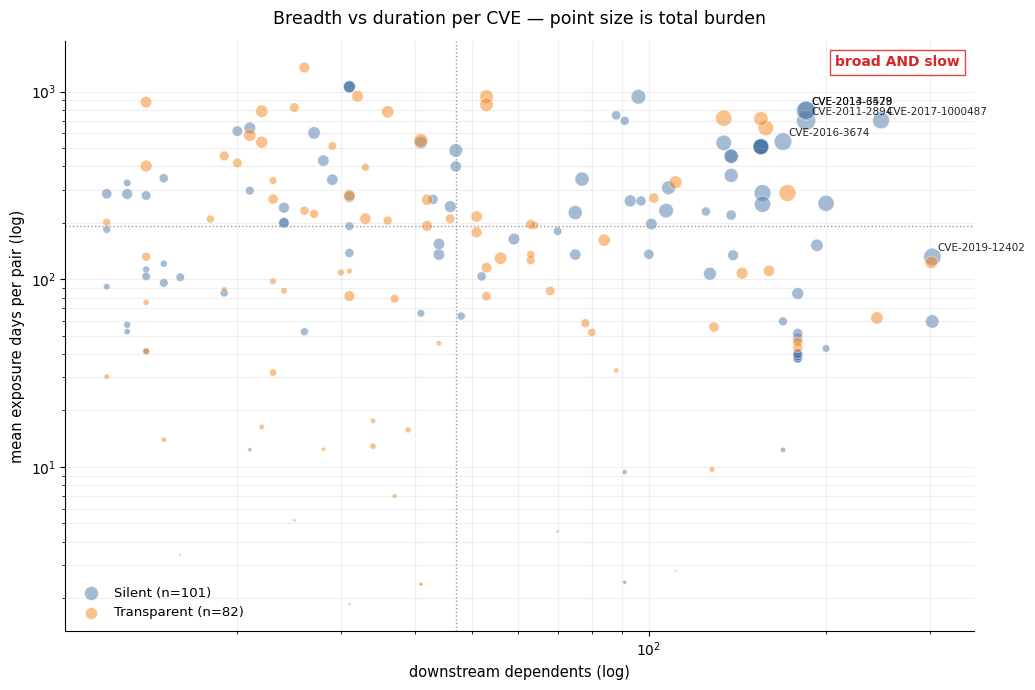

Correlation, log(dependents) vs log(exposure days per pair): 0.003

Near zero: reach and duration are INDEPENDENT.
Burden concentrates more than breadth simply because it multiplies two
independent distributions, not because broad CVEs are also slow. Reach and
duration are separate risk axes: a CVE ranked worst on one is not ranked
worst on the other. The zero overlap between T2 (top by breadth) and T6
(top by burden) is the same fact seen from the other side.


In [30]:
plot_df = cve_burden[(cve_burden.dependents > 0) & (cve_burden.burden_disclosure > 0)].copy()
CLASS_COLORS = {'Silent': '#4c78a8', 'Transparent': '#f58518'}

fig, ax = plt.subplots(figsize=(10.5, 7))
for c, col in CLASS_COLORS.items():
    s = plot_df[plot_df['class'].eq(c)]
    ax.scatter(s.dependents, s.burden_per_pair.clip(lower=0.5),
               s=np.sqrt(s.burden_disclosure) * 1.6, alpha=0.5, color=col,
               edgecolor='white', linewidth=0.6, label=f'{c} (n={len(s)})')

med_x, med_y = plot_df.dependents.median(), plot_df.burden_per_pair.clip(lower=0.5).median()
ax.axvline(med_x, color='#999999', ls=':', lw=1)
ax.axhline(med_y, color='#999999', ls=':', lw=1)
ax.text(0.985, 0.975, 'broad AND slow', transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#d62728', fontweight='bold',
        bbox={'facecolor': 'white', 'edgecolor': '#d62728', 'alpha': 0.85})

for _, r in plot_df.nlargest(6, 'burden_disclosure').iterrows():
    ax.annotate(r.CVE, (r.dependents, max(r.burden_per_pair, 0.5)),
                fontsize=7.5, alpha=0.85, xytext=(4, 4), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('downstream dependents (log)', fontsize=10.5)
ax.set_ylabel('mean exposure days per pair (log)', fontsize=10.5)
ax.set_title('Breadth vs duration per CVE — point size is total burden', fontsize=12.5, pad=12)
ax.legend(frameon=False, fontsize=9.5, loc='lower left')
ax.grid(alpha=0.2, which='both')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F6_breadth_vs_duration.png', dpi=200, bbox_inches='tight')
plt.show()

corr = np.corrcoef(np.log1p(plot_df.dependents), np.log1p(plot_df.burden_per_pair))[0, 1]
print(f'Correlation, log(dependents) vs log(exposure days per pair): {corr:.3f}')
print()
if abs(corr) < 0.10:
    print('Near zero: reach and duration are INDEPENDENT.')
    print('Burden concentrates more than breadth simply because it multiplies two')
    print('independent distributions, not because broad CVEs are also slow. Reach and')
    print('duration are separate risk axes: a CVE ranked worst on one is not ranked')
    print('worst on the other. The zero overlap between T2 (top by breadth) and T6')
    print('(top by burden) is the same fact seen from the other side.')
elif corr > 0:
    print('Positive: broad CVEs are also slower, so the two risks compound.')
else:
    print('Negative: broad CVEs are mitigated faster, so the risks partly offset.')

---
## Model — what drives burden?

Burden per CVE is a positive, heavily skewed quantity, so a **Gamma GLM with a log link** is
the right family. `log(pairs)` enters as an offset, which turns the outcome into burden *per
observed pair* and removes the confound from uneven observation counts.

Fitted by maximum likelihood (no `statsmodels` installed); CIs from a bootstrap over CVEs.

In [31]:
mdf = cve_burden[cve_burden.burden_disclosure > 0].copy()
mdf['is_transparent'] = mdf['class'].eq('Transparent').astype(int)
mdf['sev_high'] = mdf.severity.isin(['Critical', 'High']).astype(int)
mdf['log_dependents'] = np.log1p(mdf.dependents)

FEATURES = ['is_transparent', 'sev_high', 'log_dependents']
Xr = mdf[FEATURES].to_numpy(float)
Xm, Xs = Xr.mean(0), Xr.std(0); Xs[Xs == 0] = 1
Xz = (Xr - Xm) / Xs
y = mdf.burden_disclosure.to_numpy(float)
offset = np.log(mdf.pairs.to_numpy(float))

def gamma_fit(X, y, off):
    X = np.column_stack([np.ones(len(X)), X])
    def nll(p):
        b, lk = p[:-1], p[-1]
        k = np.exp(lk)
        mu = np.exp(np.clip(X @ b + off, -25, 25))
        return -np.sum((k - 1) * np.log(y) - y * k / mu - k * np.log(mu / k) - gammaln(k))
    p0 = np.zeros(X.shape[1] + 1)
    p0[0] = np.log(max((y / np.exp(off)).mean(), 1e-3))
    return minimize(nll, p0, method='BFGS', options={'maxiter': 900}).x[1:-1]

point = gamma_fit(Xz, y, offset)
idx = np.arange(len(mdf))
draws = []
for _ in range(1000):
    s = rng.choice(idx, len(idx), replace=True)
    try:
        draws.append(gamma_fit(Xz[s], y[s], offset[s]))
    except Exception:
        continue
draws = np.array(draws)

gamma_out = pd.DataFrame({
    'Predictor': FEATURES,
    'Multiplier': np.exp(point).round(3),
    'CI low': np.exp(np.percentile(draws, 2.5, axis=0)).round(3),
    'CI high': np.exp(np.percentile(draws, 97.5, axis=0)).round(3),
})
gamma_out['Significant'] = np.where(
    (gamma_out['CI low'] > 1) | (gamma_out['CI high'] < 1), 'yes', 'no')
display(gamma_out)

print(f'n CVEs = {len(mdf)} | bootstraps = {len(draws)}')
print('Multiplier per 1 SD, on burden per observed pair.')
print('Below 1 for is_transparent means transparent CVEs generate LESS exposure per pair.')

,Predictor,Multiplier,CI low,CI high,Significant
0,is_transparent,0.937,0.794,1.097,no
1,sev_high,0.931,0.770,1.087,no
2,log_dependents,0.968,0.824,1.129,no


n CVEs = 183 | bootstraps = 1000
Multiplier per 1 SD, on burden per observed pair.
Below 1 for is_transparent means transparent CVEs generate LESS exposure per pair.


---
## Headline numbers

In [32]:
head = {
    'Observed pairs': len(master),
    'CVEs': master.CVE.nunique(),
    'Downstream repos': master.downstream_repo.nunique(),
    'Pairs exposed past disclosure': int(master.exposed_past_disclosure.sum()),
    'Burden(disclosure), downstream-days': int(master.exposure_days_disclosure.sum()),
    'Burden(disclosure), downstream-years': round(master.exposure_days_disclosure.sum() / 365.25, 1),
    'Burden(release), downstream-days': int(master.exposure_days_release.sum()),
    'Median exposure days per exposed pair': round(
        master.loc[master.exposed_past_disclosure == 1, 'delay_disclosure'].median(), 1),
    'Burden Gini': round(g_burden, 3),
    'Top 10% of CVEs, share of burden': f'{100 * np.sort(burden_vals)[::-1][:max(1, len(burden_vals) // 10)].sum() / burden_vals.sum():.1f}%',
}
display(pd.DataFrame([head]).T.rename(columns={0: 'Value'}))

print()
print('For the paper:')
print(f'  Across {master.exposed_past_disclosure.sum():,} downstream projects that were still')
print(f'  running a vulnerable version when the CVE became public, we observe')
print(f'  {master.exposure_days_disclosure.sum():,.0f} downstream-days '
      f'({master.exposure_days_disclosure.sum() / 365.25:,.0f} project-years) of post-disclosure exposure.')
print('  This is a lower bound: it counts only mitigations present in RESPONSE.csv.')

,Value
Observed pairs,1677
CVEs,191
Downstream repos,742
Pairs exposed past disclosure,1430
"Burden(disclosure), downstream-days",360556
"Burden(disclosure), downstream-years",987.2
"Burden(release), downstream-days",481648
Median exposure days per exposed pair,88.1
Burden Gini,0.608
"Top 10% of CVEs, share of burden",43.8%



For the paper:
  Across 1,430 downstream projects that were still
  running a vulnerable version when the CVE became public, we observe
  360,557 downstream-days (987 project-years) of post-disclosure exposure.
  This is a lower bound: it counts only mitigations present in RESPONSE.csv.


---
## Save

In [33]:
T5.to_csv(OUT / 'T5_burden_by_pattern.csv', index=False)
T6.to_csv(OUT / 'T6_top_cves_by_burden.csv', index=False)
gamma_out.to_csv(OUT / 'T5b_burden_model.csv', index=False)
cve_burden.to_csv(OUT / 'rq2_burden_per_cve.csv', index=False)

for f in ['T5_burden_by_pattern.csv', 'T6_top_cves_by_burden.csv', 'T5b_burden_model.csv',
          'rq2_burden_per_cve.csv', 'F5_lorenz_burden_vs_breadth.png',
          'F6_breadth_vs_duration.png']:
    print(f)

T5_burden_by_pattern.csv
T6_top_cves_by_burden.csv
T5b_burden_model.csv
rq2_burden_per_cve.csv
F5_lorenz_burden_vs_breadth.png
F6_breadth_vs_duration.png
